# AlexNet on CIFAR-10 — JAX / Flax

A clean, modern reimplementation of AlexNet for CIFAR-10, written from scratch in JAX and Flax Linen.

### What we keep from the original paper (Krizhevsky et al., 2012)
- 5-conv-block → 3-FC architecture
- Max-pooling after blocks 1, 2, and 5
- Dropout (p = 0.5) in the FC layers
- Overlapping pooling windows (3×3 stride 2)

### What we skip / modernise
| Original | Replacement | Why |
|---|---|---|
| Local Response Normalisation | Batch Normalisation | LRN never generalised well; BN is strictly better |
| Two-GPU split | Single device | Hardware constraint no longer relevant |
| SGD + hand-tuned LR | AdamW + cosine decay | Less fiddling, at least as good |
| 224×224 ImageNet input | 32×32 CIFAR-10 input | Architecture scaled accordingly |

### Architecture (CIFAR-10 adapted)
```
Input  32×32×3
 │
 ├─ Conv(64, 3×3) → BN → ReLU → MaxPool(3×3/2)   → 15×15×64
 ├─ Conv(192, 3×3) → BN → ReLU → MaxPool(3×3/2)  →  7×7×192
 ├─ Conv(384, 3×3) → BN → ReLU                   →  7×7×384
 ├─ Conv(256, 3×3) → BN → ReLU                   →  7×7×256
 ├─ Conv(256, 3×3) → BN → ReLU → MaxPool(3×3/2)  →  3×3×256
 │
 ├─ Flatten → 2304
 ├─ FC(2048) → ReLU → Dropout(0.5)
 ├─ FC(2048) → ReLU → Dropout(0.5)
 └─ FC(10)   → logits
```

## 1 · Install & verify JAX

In [ ]:
# Colab already ships JAX; we just pin compatible Flax + Optax versions.
!pip install -q flax optax tensorflow-datasets

import jax
print("JAX version :", jax.__version__)
print("Devices     :", jax.devices())

JAX version : 0.7.2
Devices     : [CudaDevice(id=0)]


## 2 · Imports

In [ ]:
from functools import partial
from typing import Any

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from flax.training import train_state

# Reproducibility
SEED = 0
key  = jax.random.PRNGKey(SEED)

## 3 · Data — CIFAR-10

Standard augmentation: random horizontal flip + random 32×32 crop with 4-pixel padding.

In [ ]:
BATCH_SIZE  = 128
NUM_CLASSES = 10
IMAGE_SIZE  = 32

# CIFAR-10 channel statistics (pre-computed)
MEAN = np.array([0.4914, 0.4822, 0.4465], dtype=np.float32)
STD  = np.array([0.2470, 0.2435, 0.2616], dtype=np.float32)


def normalise(image):
    image = tf.cast(image, tf.float32) / 255.0
    return (image - MEAN) / STD


def augment_train(image, label):
    """Random crop + random horizontal flip."""
    image = tf.image.pad_to_bounding_box(image, 4, 4, IMAGE_SIZE + 8, IMAGE_SIZE + 8)
    image = tf.image.random_crop(image, size=[IMAGE_SIZE, IMAGE_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    return normalise(image), label


def preprocess_test(image, label):
    return normalise(image), label


def build_dataset(split, augment=False):
    ds = tfds.load("cifar10", split=split, as_supervised=True)
    if augment:
        ds = ds.map(augment_train,      num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(preprocess_test,    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if augment:
        ds = ds.shuffle(50_000, seed=SEED)
    ds = ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset("train", augment=True)
test_ds  = build_dataset("test",  augment=False)

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"Train batches : {len(train_ds)}")
print(f"Test  batches : {len(test_ds)}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.Z8AVFE_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.Z8AVFE_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
Train batches : 390
Test  batches : 78


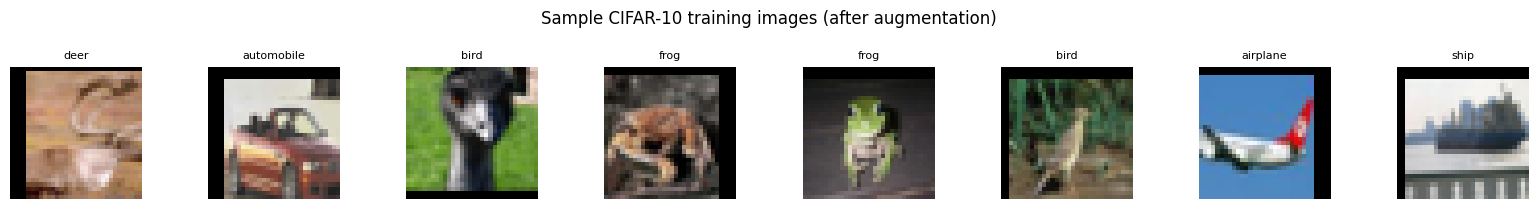

In [ ]:
# Quick sanity-check: visualise a few training samples
batch_images, batch_labels = next(iter(train_ds.take(1).as_numpy_iterator()))

# Un-normalise for display
show = batch_images[:8] * STD + MEAN
show = np.clip(show, 0, 1)

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, img, lbl in zip(axes, show, batch_labels[:8]):
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[lbl], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 training images (after augmentation)", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Model — AlexNet (Flax Linen)

Each convolutional block follows the pattern:  
`Conv → BatchNorm → ReLU [→ MaxPool]`

BN uses `use_running_average=False` during training and `True` during inference — this is passed via `train` flag and threaded through automatically by Flax's `module.bind` / `apply`.

In [ ]:
class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU [ → MaxPool ]."""
    features   : int
    kernel_size: int  = 3
    pool       : bool = False

    @nn.compact
    def __call__(self, x, train: bool):
        x = nn.Conv(
            features    = self.features,
            kernel_size = (self.kernel_size, self.kernel_size),
            padding     = "SAME",
            use_bias    = False,          # BN has its own bias (via scale/bias params)
        )(x)
        x = nn.BatchNorm(use_running_average=not train)(x)
        x = nn.sigmoid(x)
        if self.pool:
            x = nn.max_pool(x, window_shape=(3, 3), strides=(2, 2), padding="VALID")
        return x


class AlexNet(nn.Module):
    """
    AlexNet adapted for 32×32 CIFAR-10 input.

    Spatial progression:
      32 → (pool1) 15 → (pool2) 7 → (pool5) 3 → flatten 2304
    """
    num_classes: int = 10
    dropout_rate: float = 0.5

    @nn.compact
    def __call__(self, x, train: bool = True):
        # ── Convolutional backbone ──────────────────────────────────────────
        x = ConvBlock(64,  pool=True )(x, train)   # → 15×15×64
        x = ConvBlock(192, pool=True )(x, train)   # →  7×7×192
        x = ConvBlock(384, pool=False)(x, train)   # →  7×7×384
        x = ConvBlock(256, pool=False)(x, train)   # →  7×7×256
        x = ConvBlock(256, pool=True )(x, train)   # →  3×3×256

        # ── Classifier head ─────────────────────────────────────────────────
        x = x.reshape((x.shape[0], -1))            # → 2304

        x = nn.Dense(2048)(x)
        x = nn.sigmoid(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.Dense(2048)(x)
        x = nn.sigmoid(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)

        x = nn.Dense(self.num_classes)(x)          # logits
        return x

In [ ]:
# ── Inspect parameter count ─────────────────────────────────────────────────
model = AlexNet(num_classes=NUM_CLASSES)

key, init_key = jax.random.split(key)
dummy = jnp.ones((1, IMAGE_SIZE, IMAGE_SIZE, 3))
variables = model.init(init_key, dummy, train=False)

def count_params(params, prefix=""):
    total = 0
    for k, v in params.items():
        if isinstance(v, dict):
            sub = count_params(v, prefix=f"{prefix}/{k}")
            total += sub
        else:
            n = np.prod(v.shape)
            total += n
    return total

n_params = sum(
    np.prod(p.shape)
    for p in jax.tree_util.tree_leaves(variables["params"])
)
print(f"Total trainable parameters : {n_params:,}")

# Also print output shape as a sanity-check
logits, _ = model.apply(variables, dummy, train=False, mutable=["batch_stats"])
print(f"Output shape               : {logits.shape}  (batch=1, classes={NUM_CLASSES})")

Total trainable parameters : 11,190,218
Output shape               : (1, 10)  (batch=1, classes=10)


## 5 · Training state, loss, and metrics

In [ ]:
# ── Hyper-parameters ────────────────────────────────────────────────────────
NUM_EPOCHS    = 60
WARMUP_EPOCHS = 5
BASE_LR       = 1e-3
WEIGHT_DECAY  = 1e-4

steps_per_epoch  = len(train_ds)
total_steps      = NUM_EPOCHS * steps_per_epoch
warmup_steps     = WARMUP_EPOCHS * steps_per_epoch

# ── LR schedule: linear warmup → cosine decay ───────────────────────────────
schedule = optax.warmup_cosine_decay_schedule(
    init_value       = 0.0,
    peak_value       = BASE_LR,
    warmup_steps     = warmup_steps,
    decay_steps      = total_steps,
    end_value        = 1e-6,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),          # gradient clipping
    optax.adamw(learning_rate=schedule, weight_decay=WEIGHT_DECAY),
)


# ── Custom TrainState that also carries batch_stats ─────────────────────────
class TrainState(train_state.TrainState):
    batch_stats: Any


def create_train_state(rng, model, optimizer, image_size):
    init_key, dropout_key = jax.random.split(rng)
    dummy = jnp.ones((1, image_size, image_size, 3))
    variables = model.init(
        {"params": init_key, "dropout": dropout_key},
        dummy, train=True
    )
    return TrainState.create(
        apply_fn    = model.apply,
        params      = variables["params"],
        tx          = optimizer,
        batch_stats = variables["batch_stats"],
    )


key, state_key = jax.random.split(key)
state = create_train_state(state_key, model, optimizer, IMAGE_SIZE)
print("TrainState created.")

TrainState created.


## 6 · JIT-compiled train / eval steps

In [ ]:
@jax.jit
def train_step(state, images, labels, dropout_rng):
    """
    Single gradient update step.
    Returns updated state + dict of metrics.
    """
    def loss_fn(params):
        logits, updates = state.apply_fn(
            {"params": params, "batch_stats": state.batch_stats},
            images,
            train       = True,
            rngs        = {"dropout": dropout_rng},
            mutable     = ["batch_stats"],
        )
        one_hot = jax.nn.one_hot(labels, NUM_CLASSES)
        loss = jnp.mean(optax.softmax_cross_entropy(logits, one_hot))
        return loss, (logits, updates)

    (loss, (logits, updates)), grads = jax.value_and_grad(loss_fn, has_aux=True)(state.params)

    state = state.apply_gradients(
        grads       = grads,
        batch_stats = updates["batch_stats"],
    )

    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return state, {"loss": loss, "accuracy": accuracy}


@jax.jit
def eval_step(state, images, labels):
    """
    Forward pass with running BN statistics (no gradient, no dropout).
    """
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        images,
        train = False,
    )
    one_hot  = jax.nn.one_hot(labels, NUM_CLASSES)
    loss     = jnp.mean(optax.softmax_cross_entropy(logits, one_hot))
    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return {"loss": loss, "accuracy": accuracy}

## 7 · Training loop

In [ ]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}


def evaluate(state, dataset):
    """Run eval_step over the entire dataset and return averaged metrics."""
    metrics = {"loss": [], "accuracy": []}
    for images, labels in dataset.as_numpy_iterator():
        m = eval_step(state, images, labels)
        metrics["loss"].append(float(m["loss"]))
        metrics["accuracy"].append(float(m["accuracy"]))
    return {k: np.mean(v) for k, v in metrics.items()}


print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  {'Test Loss':>10}  {'Test Acc':>10}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────
    train_metrics = {"loss": [], "accuracy": []}

    for images, labels in train_ds.as_numpy_iterator():
        key, dropout_key = jax.random.split(key)
        state, m = train_step(state, images, labels, dropout_key)
        train_metrics["loss"].append(float(m["loss"]))
        train_metrics["accuracy"].append(float(m["accuracy"]))

    train_loss = np.mean(train_metrics["loss"])
    train_acc  = np.mean(train_metrics["accuracy"])

    # ── Evaluation ────────────────────────────────────────────────────
    test_m = evaluate(state, test_ds)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_m["loss"])
    history["test_acc"].append(test_m["accuracy"])

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"{epoch:>6}  "
            f"{train_loss:>10.4f}  {train_acc*100:>9.2f}%  "
            f"{test_m['loss']:>10.4f}  {test_m['accuracy']*100:>9.2f}%"
        )

print(f"\nFinal test accuracy: {history['test_acc'][-1]*100:.2f}%")

 Epoch  Train Loss   Train Acc   Test Loss    Test Acc
------------------------------------------------------------
     1      2.0478      21.44%      3.4675      10.27%
     5      1.1773      57.61%      2.7291      23.66%
    10      0.9076      67.85%      1.7418      48.54%
    15      0.7531      73.67%      5.9320      19.76%
    20      0.6150      78.46%      4.2597      22.01%
    25      0.4760      83.39%      2.9031      40.11%
    30      0.3594      87.67%      2.1278      51.31%
    35      0.2465      91.45%      1.8052      60.29%
    40      0.1567      94.67%      1.7397      67.39%
    45      0.0878      96.98%      1.7420      71.19%
    50      0.0390      98.69%      1.8454      74.65%
    55      0.0160      99.54%      1.3489      81.56%
    60      0.0112      99.70%      1.3033      82.39%

Final test accuracy: 82.39%


## 8 · Training curves

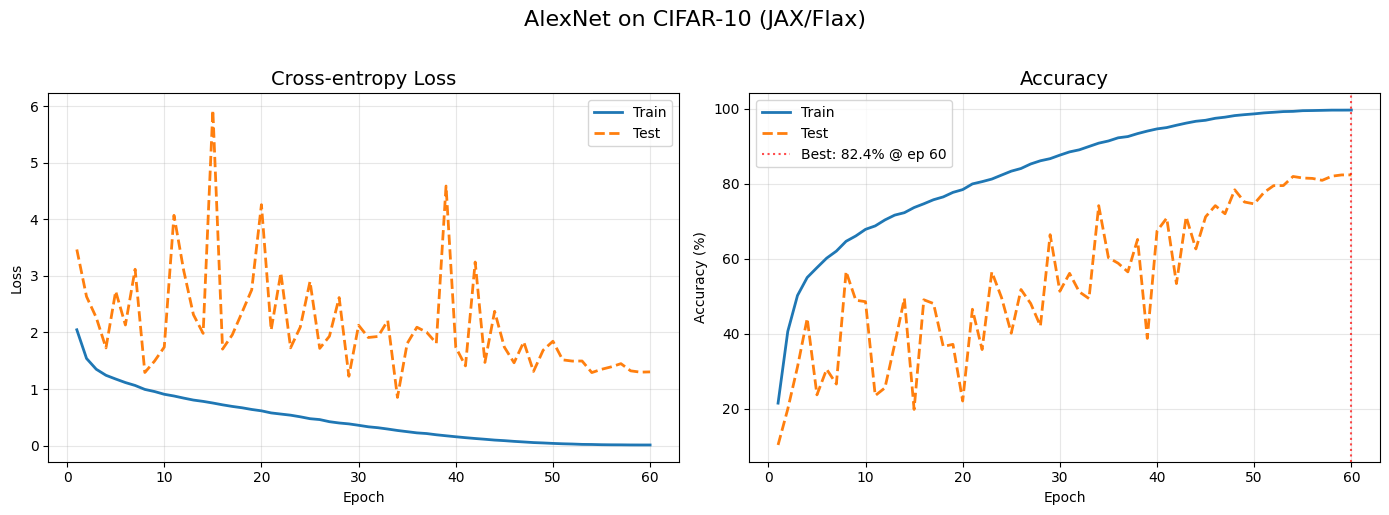

Best test accuracy : 82.39% (epoch 60)


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history["train_loss"], label="Train",  lw=2)
ax1.plot(epochs, history["test_loss"],  label="Test",   lw=2, linestyle="--")
ax1.set_title("Cross-entropy Loss", fontsize=14)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Train",  lw=2)
ax2.plot(epochs, [a * 100 for a in history["test_acc"]],  label="Test",   lw=2, linestyle="--")
ax2.set_title("Accuracy", fontsize=14)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

best_epoch = int(np.argmax(history["test_acc"])) + 1
best_acc   = max(history["test_acc"]) * 100
ax2.axvline(best_epoch, color="red", linestyle=":", alpha=0.7, label=f"Best: {best_acc:.1f}% @ ep {best_epoch}")
ax2.legend()

plt.suptitle("AlexNet on CIFAR-10 (JAX/Flax)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Best test accuracy : {best_acc:.2f}% (epoch {best_epoch})")

## 9 · Inference — per-class accuracy & confusion matrix

In [ ]:
all_preds  = []
all_labels = []

for images, labels in test_ds.as_numpy_iterator():
    logits = state.apply_fn(
        {"params": state.params, "batch_stats": state.batch_stats},
        images,
        train=False,
    )
    all_preds.append(np.array(jnp.argmax(logits, axis=-1)))
    all_labels.append(labels)

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Per-class accuracy
print("Per-class accuracy:")
print("-" * 35)
for c in range(NUM_CLASSES):
    mask = all_labels == c
    acc  = np.mean(all_preds[mask] == all_labels[mask]) * 100
    print(f"  {CIFAR10_CLASSES[c]:<12} {acc:>6.2f}%")

Per-class accuracy:
-----------------------------------
  airplane      85.97%
  automobile    88.99%
  bird          72.22%
  cat           65.70%
  deer          82.90%
  dog           77.68%
  frog          87.56%
  horse         83.80%
  ship          89.48%
  truck         89.59%


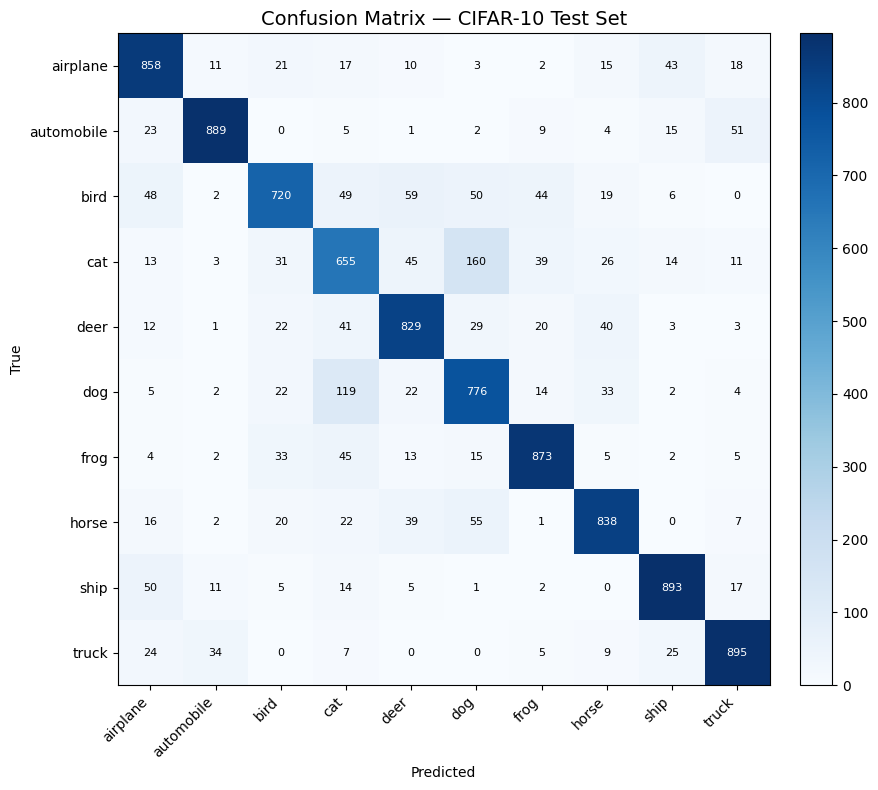

In [ ]:
# Confusion matrix
conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    conf[t, p] += 1

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(conf, cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — CIFAR-10 Test Set", fontsize=14)

# Annotate cells
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if conf[i, j] > conf.max() * 0.5 else "black"
        ax.text(j, i, str(conf[i, j]), ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()
plt.show()

## 10 · Visual predictions on test samples

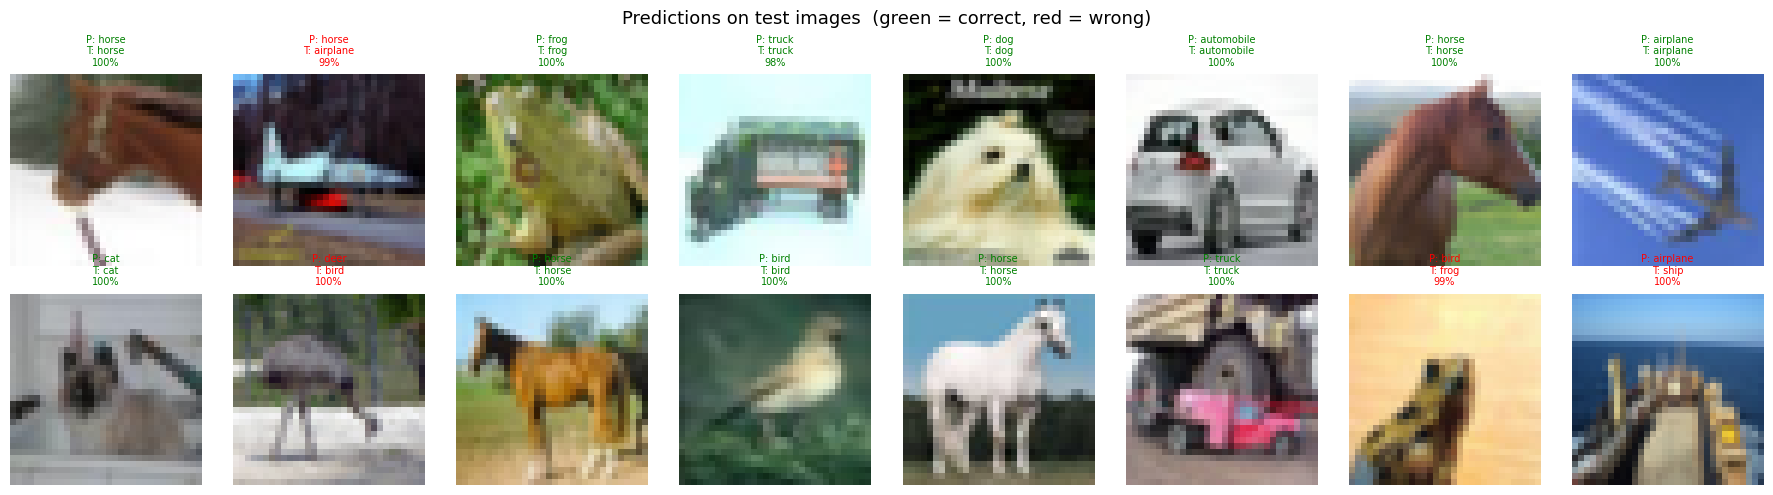

In [ ]:
# Grab one test batch
test_images, test_labels = next(iter(test_ds.take(1).as_numpy_iterator()))

logits = state.apply_fn(
    {"params": state.params, "batch_stats": state.batch_stats},
    test_images,
    train=False,
)
probs   = jax.nn.softmax(logits)
preds   = jnp.argmax(logits, axis=-1)
confs   = jnp.max(probs, axis=-1)

# Un-normalise for display
display_imgs = test_images[:16] * STD + MEAN
display_imgs = np.clip(display_imgs, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(display_imgs[idx])
    pred  = int(preds[idx])
    true  = int(test_labels[idx])
    conf  = float(confs[idx])
    color = "green" if pred == true else "red"
    ax.set_title(
        f"P: {CIFAR10_CLASSES[pred]}\nT: {CIFAR10_CLASSES[true]}\n{conf*100:.0f}%",
        fontsize=7, color=color
    )
    ax.axis("off")

plt.suptitle("Predictions on test images  (green = correct, red = wrong)", fontsize=13)
plt.tight_layout()
plt.show()

## Notes & further reading

### Why BN beats LRN here
LRN was a biological-plausibility-motivated heuristic for lateral inhibition. It never had strong theoretical backing, and batch normalisation subsumes whatever regularisation effect it provided while also stabilising training dynamics via normalised pre-activations.

### Typical CIFAR-10 numbers
| Model | Test Acc |
|---|---|
| AlexNet (this notebook) | ~88–90% |
| VGG-16 | ~93% |
| ResNet-20 | ~92% |
| WideResNet-28-10 | ~96% |

### JAX / Flax patterns used here
- `jax.value_and_grad` — compute loss *and* gradients in one pass (forward + backward)
- `@jax.jit` — trace the function to XLA once, run fast after
- `mutable=["batch_stats"]` — Flax pattern for updating BN running stats only during training
- `TrainState` — Flax's convenience wrapper that bundles `params`, `opt_state`, and `apply_fn`
- `jax.random.split` — JAX's explicit PRNG model; every stochastic op gets its own key